In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:\ML-Projects\HeartApp Project\HeartDesies.csv')

# EDA & Data Cleaning

In [14]:
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()

Shape of the dataset: (918, 12)

First 5 rows of the dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
# statistical summary of the dataset
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [24]:
print("Number of missing values in each column:")
print(df.isnull().sum())

print("Number of duplicate rows:", df.duplicated().sum())

Number of missing values in each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Number of duplicate rows: 0


Value counts of the target variable:
Axes(0.125,0.11;0.775x0.77)


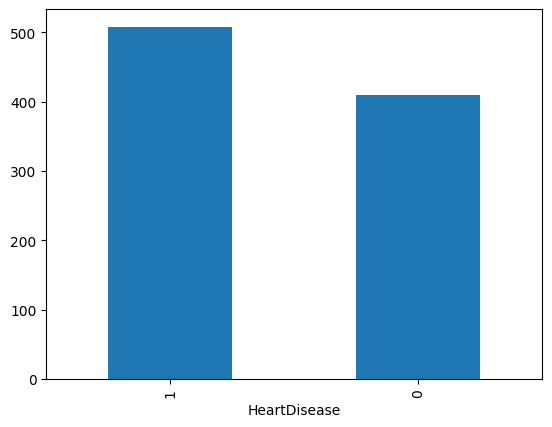

In [25]:
print("Value counts of the target variable:")
print(df['HeartDisease'].value_counts().plot(kind='bar'))

In [32]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


Distribution of key numerical features:


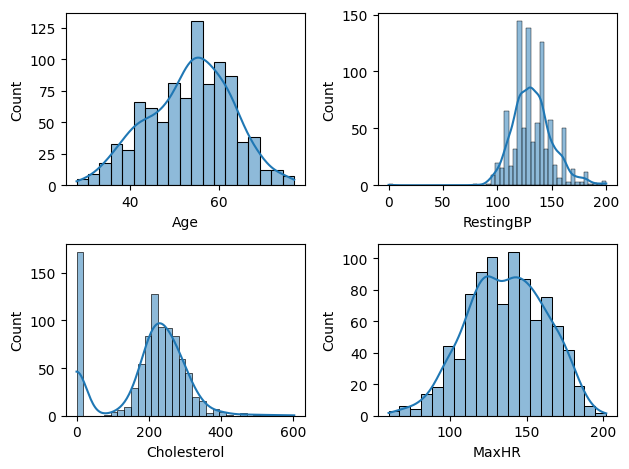

In [30]:
print("Distribution of key numerical features:")
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde=True)

# This helps in identifying skewness, outliers, and the overall shape of these important numerical features.
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [38]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [42]:
ch_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].median()
ch_mean

np.float64(237.0)

In [43]:
# Replacing all zero values in the 'Cholesterol' column with the calculated mean (excluding zeros)
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

In [44]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
101      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [45]:
RBP_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].median()
RBP_mean

np.float64(130.0)

In [46]:
# This imputation strategy helps in handling missing data by filling it with a representative value.
# The values are then rounded to two decimal places for consistency.
df['RestingBP'] = df['RestingBP'].replace(0,RBP_mean)

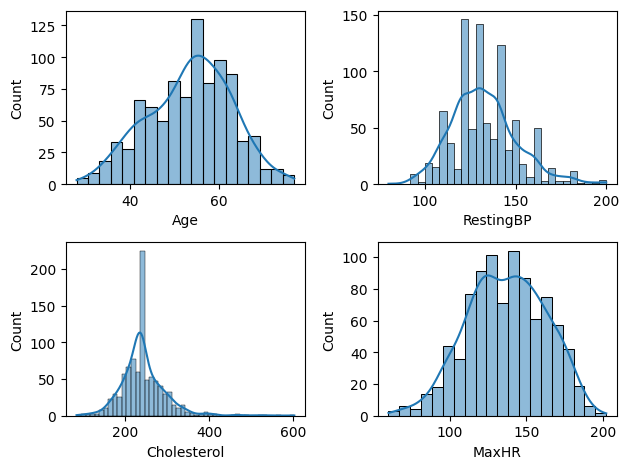

In [47]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var], kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

1️⃣ ATA – Atypical Angina

Chest pain but not classic heart pain

Not strongly related to physical exertion

Usually less dangerous

Often NO heart disease (as seen in your blue bars)

2️⃣ NAP – Non-Anginal Pain

Pain not related to the heart

Could be muscle pain, gastric pain, etc.

Mostly NOT heart disease

Moderate number of cases in both categories

3️⃣ ASY – Asymptomatic (No Pain)

⭐ Most important category

Means no chest pain at all

But ECG or other tests show heart issues

Very HIGH risk

In your graph, ASY has the highest count for HeartDisease = 1 (orange bar)

Why?
Because many heart patients show silent symptoms — no chest pain but still serious blockage.

4️⃣ TA – Typical Angina

Classic chest pain due to exercise or stress

Pain goes away with rest

Here you see low number of cases, but some are heart disease.

Distribution of Chest Pain Types by Heart Disease Status:


<Axes: xlabel='ChestPainType', ylabel='count'>

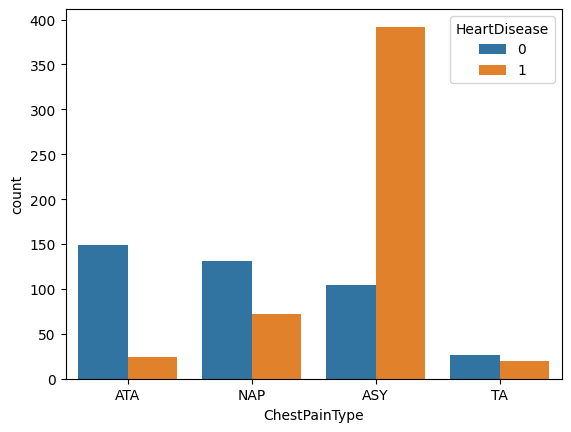

In [49]:
# ATA: Unusual chest pain     # NAP: Pain not related to heart
# ASY: No pain but highest risk   # TA: Classic heart pain
print("Distribution of Chest Pain Types by Heart Disease Status:")
sns.countplot(x = df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

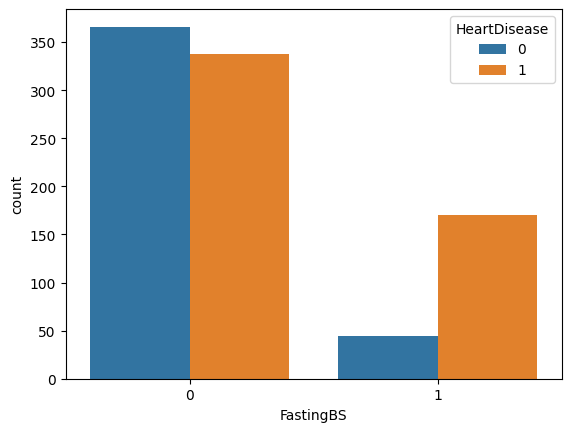

In [50]:
# FastingBS means Fasting Blood Sugar. It has only two values:
# 0 → normal (≤120 mg/dL) # 1 → high (>120 mg/dL)
sns.countplot(x = df['FastingBS'], hue=df['HeartDisease'])

<Axes: xlabel='Cholesterol'>

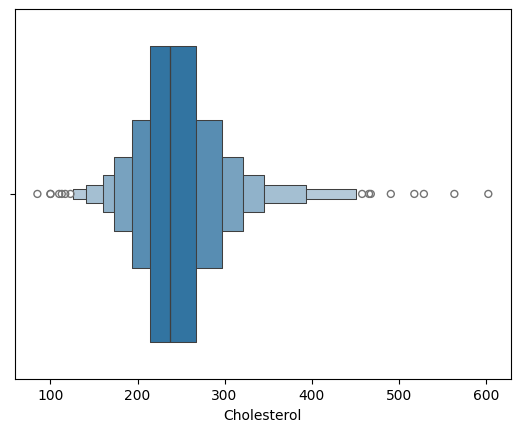

In [51]:
# “Boxen plot shows how cholesterol values are spread and highlights extreme values clearly.”
sns.boxenplot(x = df['Cholesterol'])

<Axes: >

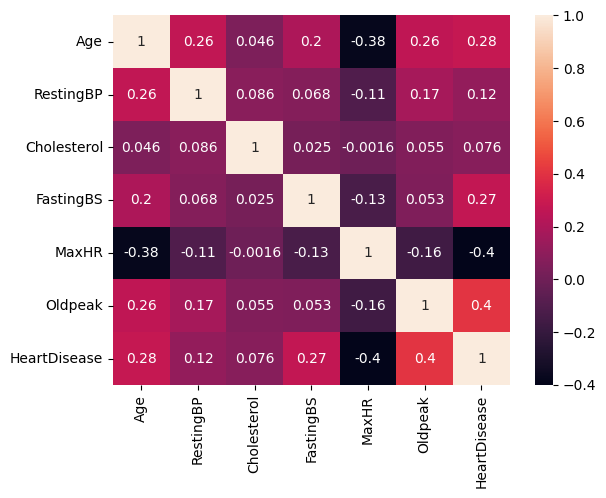

In [52]:
# +1 → perfect positive relationship  # -1 → perfect negative relationship
# 0 → no relationship
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Preprocessing

In [58]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [57]:
df_encoded = df_encode.astype(int)
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [59]:
df_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [61]:
x = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [68]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [69]:
# Initializing StandardScaler to scale the features.
# Feature scaling is important for many machine learning algorithms, especially those that rely on distance calculations (e.g., KNN, SVM) or gradient descent (e.g., Logistic Regression).
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled)
print(x_test_scaled)

[[-1.24506731 -0.74559246 -0.07753369 ... -0.83846064 -1.03325003
  -0.84792072]
 [-1.8862362  -0.18250483 -0.69074241 ... -0.83846064 -1.03325003
   1.17935554]
 [ 0.25099346  0.94367043 -0.6116187  ...  1.19266183  0.96781995
  -0.84792072]
 ...
 [ 0.67843939 -0.18250483  0.17961836 ...  1.19266183 -1.03325003
   1.17935554]
 [ 0.67843939  1.05628795 -0.13687647 ...  1.19266183 -1.03325003
   1.17935554]
 [-1.45879027  0.94367043  2.92916715 ... -0.83846064  0.96781995
  -0.84792072]]
[[ 9.99023837e-01  3.80582797e-01 -9.67675383e-01 ... -8.38460638e-01
  -1.03325003e+00  1.17935554e+00]
 [-6.95909930e-02  6.62126612e-01  5.42156390e+00 ... -8.38460638e-01
   9.67819953e-01 -8.47920724e-01]
 [ 1.21274680e+00  1.50675806e+00 -1.36876466e-01 ... -8.38460638e-01
   9.67819953e-01 -8.47920724e-01]
 ...
 [ 1.10588532e+00  4.36891560e-01  1.59001998e-03 ...  1.19266183e+00
   9.67819953e-01 -8.47920724e-01]
 [-4.97036925e-01 -1.82504833e-01  4.36770405e-01 ... -8.38460638e-01
  -1.03325003

In [70]:
# Logistic Regression is a linear model used for binary classification.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
lgr = LogisticRegression()
lgr.fit(x_train_scaled, y_train)
predict = lgr.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[68 16]
 [ 9 91]]
              precision    recall  f1-score   support

           0       0.88      0.81      0.84        84
           1       0.85      0.91      0.88       100

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [71]:
# KNN is a non-parametric, lazy learning algorithm that classifies data points based on the majority class of its 'k' nearest neighbors.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)
predict = knn.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[66 14]
 [11 93]]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        80
           1       0.87      0.89      0.88       104

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [72]:
# Decision Trees are non-linear models that make decisions by splitting data based on feature values.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
dtc=DecisionTreeClassifier()
dtc.fit(x_train_scaled, y_train)
predict=dtc.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[63 26]
 [14 81]]
              precision    recall  f1-score   support

           0       0.82      0.71      0.76        89
           1       0.76      0.85      0.80        95

    accuracy                           0.78       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



In [73]:
# SVC is a powerful model for classification that finds the optimal hyperplane to separate classes.
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_scaled, y_train)
predict = svc.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[65 16]
 [12 91]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        81
           1       0.85      0.88      0.87       103

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



In [74]:
# This might be for re-evaluation or an alternative run with potentially different parameters if this were a full experiment.
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train_scaled, y_train)
predict = dtc.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[64 23]
 [13 84]]
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        87
           1       0.79      0.87      0.82        97

    accuracy                           0.80       184
   macro avg       0.81      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



In [75]:
# Naive Bayes classifiers are a family of simple probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features.
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)
predict = gnb.predict(x_test_scaled)
cm = confusion_matrix(predict,y_test)
cr = classification_report(predict,y_test)
print(cm)
print(cr)

[[69 20]
 [ 8 87]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.83        89
           1       0.81      0.92      0.86        95

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [83]:
from pathlib import Path
import pickle
import json

base = Path(r'D:\ML-Projects\HeartApp Project')

with open(base / 'classifier.pkl', 'wb') as f:
    pickle.dump(knn, f)

with open(base / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

features = x.columns.tolist()
with open(base / 'features.json', 'w') as f:
    json.dump(features, f)
